# Apprentissage d'une loi GSM pour une loi visco-plastique

We want to learn the viscosity behaviour following the GSM formulation. It is based on a two potential formulation defined by the free energy $\Psi(\bm  \varepsilon,\bm  \alpha_i)$ and the $\Phi(\dot{\bm  \alpha}_i)$. The evolution of $N_{var}$ internal variables $\alpha_i \in \text{Sym}(3)$ is obtain with the incremental formulation. To verify thermodynamical conditions, the two potential must be convex with respect to their respective inputs.

First we will deal with the linear viscoelasticity which define the potential as

$$
\Psi(\bm  \varepsilon,\bm  \varepsilon_p, p) = \frac{1}{2}(\bm  \varepsilon- \bm  \varepsilon^{an}):\mathbb C_e:(\bm  \varepsilon-\bm \varepsilon^{an}) + \Psi_p(p) + \Psi_\alpha(\bm \varepsilon^{an})
$$

where $\mathbb C_e$ the elastic stiffness tensors, $\Psi_p$ a neural network for the hardening variable.

We also made the hypothesis that those two tensors are isotrope such as they could be defined with only two parameters.

On the other hand, we define the dual dissipation potential thanks to a neural network

$$
\Phi^*(A_p, A^{an})  = \mathcal{N}_\text{ICNN}(A_p, A^{an})
$$

In [1]:
from jaxmat.tensors.utils import safe_norm, safe_sqrt
from jaxmat.utils import default_value, enforce_dtype
from jaxmat.tensors import dev

## Data : norton_implicit.mfront

In [2]:
import os
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.4"
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import pandas as pd
import jax

import jax.numpy as jnp
import equinox as eqx
from jaxmat.utils import enforce_dtype, partition_by_node_names
from jaxmat.tensors import SymmetricTensor2, main_invariants
from jaxmat.nn.icnn import ICNN, QuadICNN, NormalizedQuadICNN
from jaxmat.state import AbstractState, make_batched, SmallStrainState
import matplotlib.pyplot as plt 
from jaxmat.solvers import NewtonTrustRegion
from pt2mfront.utils.utils_hdf5 import load_from_hdf5
import jaxmat.materials as jm
import optax
from pathlib import Path

key = jax.random.PRNGKey(42)
key1, key2 = jax.random.split(key, num=2)
hdf5_path = Path("../data/dataset_norton_iso_kin_hardening_3D.h5")
strain, stress, _, _, iv, times, metadata, scalers, config, material_infos = load_from_hdf5(
            hdf5_path, "train"
        )
strain_test, stress_test, _, _, _, times_test, metadata, scalers, config, material_infos_test = load_from_hdf5(
            hdf5_path, "test"
        )

times = jnp.array(times)

strain /= scalers["std_strain"][3]
stress /= scalers["std_stress"][3]
strain_test /= scalers["std_strain"][3]
stress_test /= scalers["std_stress"][3]

In [3]:
material_infos

{'materials': [{'external_state_variables': {'Temperature': 293.15},
   'library_path': 'data/mfront/src/libUmatBehaviour.so',
   'name': 'umatnortonisokinhardening',
   'type': 'umat'}],
 'material_index': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}

In [4]:
N_step = 500
Step = 2
train_strain = SymmetricTensor2(array=strain[:,Step:N_step:Step,...])
train_stress = SymmetricTensor2(array=stress[:,Step:N_step:Step,...])
test_strain = SymmetricTensor2(array=strain_test[:,Step:N_step:Step,...])
test_stress = SymmetricTensor2(array=stress_test[:,Step:N_step:Step,...])
times = times[:,:N_step:Step]
times_test = times_test[:,:N_step:Step]

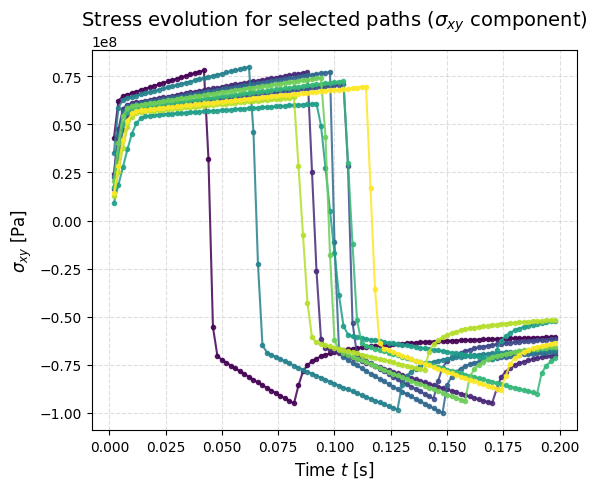

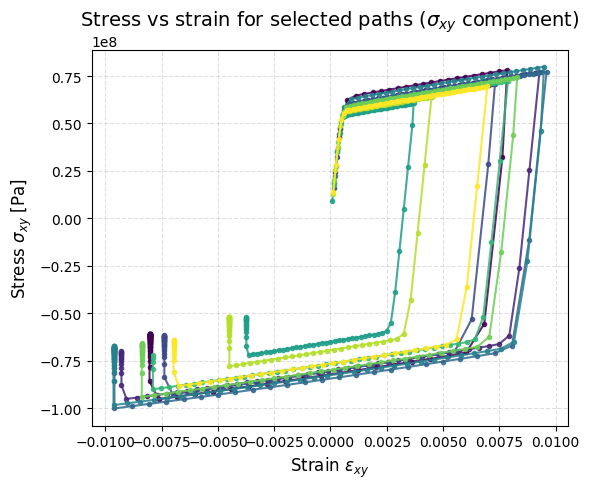

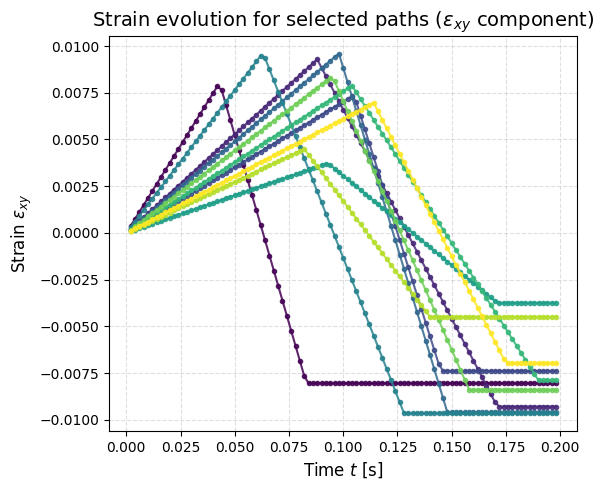

In [5]:
n_paths = 10
colors = plt.cm.viridis(jnp.linspace(0, 1, n_paths))

# --------------------------
# 1️⃣ Stress σ_xy vs temps
# --------------------------
fig, ax = plt.subplots(figsize=(6, 5))

k, l = 0, 1  # XY

for i in range(n_paths):
    ax.plot(
        times[i, 1:],  # temps
        train_stress[i, :, k, l] * scalers["std_stress"][3],  # σ_xy
        color=colors[i],
        marker='o',
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
    )

ax.set_xlabel("Time $t$ [s]", fontsize=12)
ax.set_ylabel(r"$\sigma_{xy}$ [Pa]", fontsize=12)
ax.set_title("Stress evolution for selected paths ($\sigma_{xy}$ component)", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

# --------------------------
# 2️⃣ Stress σ_xy vs strain ε_xy
# --------------------------
fig, ax = plt.subplots(figsize=(6, 5))

for i in range(n_paths):
    ax.plot(
        train_strain[i, :, k, l] * scalers["std_strain"][3],  # ε_xy
        train_stress[i, :, k, l] * scalers["std_stress"][3],  # σ_xy
        color=colors[i],
        marker='o',
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
    )

ax.set_xlabel(r"Strain $\varepsilon_{xy}$", fontsize=12)
ax.set_ylabel(r"Stress $\sigma_{xy}$ [Pa]", fontsize=12)
ax.set_title("Stress vs strain for selected paths ($\sigma_{xy}$ component)", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

# --------------------------
# 3️⃣ Strain ε_xy vs temps
# --------------------------
fig, ax = plt.subplots(figsize=(6, 5))

for i in range(n_paths):
    ax.plot(
        times[i, 1:],  # temps
        train_strain[i, :, k, l] * scalers["std_strain"][3],  # ε_xy
        color=colors[i],
        marker='o',
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
    )

ax.set_xlabel("Time $t$ [s]", fontsize=12)
ax.set_ylabel(r"Strain $\varepsilon_{xy}$", fontsize=12)
ax.set_title("Strain evolution for selected paths ($\epsilon_{xy}$ component)", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()


## Evolution function and model definition

In [6]:
from optax.tree_utils import tree_scale, tree_sub, tree_add
# define evolution function 
@eqx.filter_jit
def compute_evolution(material, epsilons, times, return_state=True):
    # Initial material state
    state0 = material.init_state()
    dt = jnp.diff(times)

    def step(state, args):
        new_epsilon_, dt_ = args

        # Update material response
        new_stress, new_state = material.constitutive_update(new_epsilon_, state, dt_)
        if return_state:
            return new_state, (new_stress, new_state)
        else: 
            return new_state, new_stress
    # Use lax.scan to loop over gamma_list efficiently
    if return_state:
        _, (sig, state) = jax.lax.scan(step, state0, (epsilons, dt))
        return sig, state
    else:
        _, sig = jax.lax.scan(step, state0, (epsilons, dt))
        return sig

batched_compute_evolution = jax.vmap(
    compute_evolution,
    in_axes=(None, 0, 0,None), 
)

In [ ]:
class InternalState(AbstractState):
    """
    Internal state for hardening viscoplasticity
    """

    p: jax.Array = eqx.field(init=False)
    """scalar """
    epsp: SymmetricTensor2 = eqx.field(default_factory=lambda: SymmetricTensor2())
    """Plastic strain tensor"""
    Nvar: int = eqx.field(static=True, default=1)

    def __post_init__(self):
        # Initialise to zero
        self.p = jnp.zeros((self.Nvar,))


# int_var = InternalState(Nvar=1)  # I use 1 additional scalar variable.
# print(int_var)
# InternalState = jm.elastoplasticity.InternalState
# 

In [84]:
class FreeEnergy(eqx.Module):
    elasticity: jm.AbstractLinearElastic  # Hooke isotrope
    nn_anelastic: ICNN  # ICNN for epsp variable
    nn_hardening: ICNN  # ICNN for p variable

    def __call__(self, eps, isv):
        """
        Compute free energy:
        psi = 0.5*(eps - sum_i alpha_p[i]) : C : (eps - sum_i alpha_p[i]) + NN(epsp) + NN(q)
        """
        epsp = isv.epsp
        psi_elastic = 0.5 * jnp.trace((eps - epsp) @ (self.elasticity.C @ (eps - epsp)))

        I1, I2, _ = main_invariants(isv.epsp)
        I1 = jnp.squeeze(I1)
        I2 = jnp.squeeze(I2)
        x = jnp.stack([I1, I2])
        s = isv.epsp.tensor - jnp.trace(isv.epsp.tensor)/3 * jnp.eye(3)
        x = 2./3. * jnp.sum(s * s)
        psi_anelastic = self.nn_anelastic(x) - self.nn_anelastic(jnp.zeros_like(x)) - jax.jvp(self.nn_anelastic,(jnp.zeros_like(x),),(x,))[1]
        psi_hardening = self.nn_hardening(isv.p) - self.nn_hardening(jnp.zeros_like(isv.p)) - jax.jvp(self.nn_hardening,(jnp.zeros_like(isv.p),),(isv.p,))[1]

        # énergie totale
        return psi_elastic + psi_hardening + psi_anelastic 

In [ ]:
class DissipationPotentialQuad(eqx.Module):
    log_visco_quad : float = enforce_dtype()
    nn_corr : ICNN
    def icnn_potential(self, A_an, A_p=None):
        """
        A_an : SymmetricTensor2 (batch Nvar, 3,3)
        A_p : jnp.ndarray (batch Nvar,) ou None
        """
        # Calcul invariants principaux du batch de A
        I1, I2, _ = main_invariants(A_an)  # shape (Nvar,)

        # Construit l'entrée du réseau
        if A_p is not None:
            I1 = jnp.atleast_1d(I1)
            I2 = jnp.atleast_1d(I2)
            A_p  = jnp.atleast_1d(A_p)
            x = jnp.concatenate([I1,I2,A_p], axis=0)
        else:
            x = I2
        return self.nn_corr(x)
    
    @property
    def visco_quad(self):
        return jnp.exp(self.log_visco_quad)
    def __call__(self, isv):
        """
        Compute free energy:
        phi = ICNN(I2(\dot epsp), \dot p)
        """
        A_an = isv.epsp.tensor
        A_p = isv.p
        I1, I2, I3 = main_invariants(A_an)
        # s_A_an = jnp.sqrt(3 / 2.0) * safe_norm(dev(A_an))
        phi_quad = 0.5 * I2 **2 / self.visco_quad
        phi = self.icnn_potential(A_an, A_p)
        return phi_quad + phi #- jax.jvp(lambda a: self.icnn_potential(SymmetricTensor2(tensor=a), A_p=jnp.zeros_like(A_p)),(jnp.zeros_like(A_p),),(A_p,),)[1]

class ICNNDissipationPotential(ICNN):
    def icnn_potential(self, A, Q=None):
        """
        A : SymmetricTensor2 (batch Nvar, 3,3)
        Q : jnp.ndarray (batch Nvar,) ou None
        """
        # Calcul invariants principµaux du batch de A
        # I1, I2, I3 = jax.vmap(main_invariants)(A)  # shape (Nvar,)
        # I1, I2, _ = main_invariants(A)
        s = A - jnp.trace(A)/3 * jnp.eye(3)
        J2 = 2./3. * jnp.sum(s * s)
        # Construit l'entrée du réseau
        if Q is not None:
            J2 = jnp.atleast_1d(J2)
            Q  = jnp.atleast_1d(Q)
            x = jnp.concatenate([J2, Q])
        else:
            x = J2
        return super().__call__(x)

    def __call__(self, isv):
        """
        isv: objet avec
            .A : SymmetricTensor2 (forces sur alpha_p)
            .Q : jnp.ndarray (forces sur q)
        """
        A_p = isv.epsp.tensor       
        Q = isv.p       

        # Potentiel pseudo-dissipatif dual
        return (
            self.icnn_potential(A_p, Q) - self.icnn_potential(jnp.zeros_like(A_p), jnp.zeros_like(Q))
            - jax.jvp(
                lambda a: self.icnn_potential(a, Q=jnp.zeros_like(Q)),
                (jnp.zeros_like(A_p),),
                (A_p,),
            )[1]
            - jax.jvp(
                lambda q: self.icnn_potential(jnp.zeros_like(A_p), Q=q),
                (jnp.zeros_like(Q),),
                (Q,),
            )[1]
        )

In [ ]:
hidden_dims = [16,16] # (16,16,16)
Nvar = 1
key = jax.random.PRNGKey(42)
key1, key2, key3 = jax.random.split(key, num=3)  # define keys for reproducibility
E_scale = 150e9 * scalers["std_strain"][3] / scalers["std_stress"][3] # 196000 * jnp.mean(jnp.abs(strain_clean[...,0,0])) / jnp.mean(jnp.abs(sig_clean[...,0,0])) #1 
nu = 0.3
elasticity = jm.LinearElasticIsotropic(E=E_scale, nu=nu)

# nn_anelastic = QuadICNN(1, hidden_dims, key1,use_quadratic_passthrough=True)  # one input the second main invariant
nn_anelastic = ICNN(1, hidden_dims, key1)
# nn_anelastic = NormalizedQuadICNN(nn_anelastic, 1)
# nn_hardening = QuadICNN(Nvar, hidden_dims, key2,use_quadratic_passthrough=True)  # Nvar inputs
nn_hardening = ICNN(Nvar, hidden_dims, key2)

# nn_hardening = NormalizedQuadICNN(nn_hardening, Nvar)

free_energy = FreeEnergy(elasticity, nn_anelastic, nn_hardening)

# dissipation_potential = ICNNDissipationPotential(Nvar + 1, hidden_dims, key3, use_quadratic_passthrough=True)
dissipation_potential = ICNNDissipationPotential(Nvar + 1, hidden_dims, key3)
# dissipation_potential = NormalizedQuadICNN(dissipation_potential, Nvar+1)

class GSM(jm.GeneralizedStandardMaterialDual):
    def make_internal_state(self):
        return InternalState()#Nvar=Nvar)

    
gsm = GSM(free_energy, dissipation_potential)
state0 = gsm.init_state()

/tmp/ipykernel_1086735/3624565758.py:28: UserWarning: Using `field(init=False)` on `equinox.Module` can lead to surprising behaviour when used around `jax.grad`. In the following example, observe how JAX computes gradients with respect to the `.len` attribute (which is a PyTree leaf passed across the `jax.grad` boundary) and that there are no gradients with respect to `.a` or `.b`:

```
import equinox as eqx
import jax
import jax.numpy as jnp

class Foo(eqx.Module):
    a: jax.Array
    b: jax.Array
    len: jax.Array = eqx.field(init=False)

    def __post_init__(self):
        self.len = jnp.sqrt(self.a**2 + self.b**2)

    def __call__(self, x):
        return self.len * x

@jax.jit
@jax.grad
def call(module, x):
    return module(x)

grads = call(Foo(jnp.array(3.0), jnp.array(4.0)), 5)
# Foo(
#   a=Array(0., dtype=float32, weak_type=True),
#   b=Array(0., dtype=float32, weak_type=True),
#   len=Array(5., dtype=float32, weak_type=True)
# )
```
  gsm = GSM(free_energy, dissipation_po

In [89]:
# Prepare data for training
# epsilons_train = SymmetricTensor2(train_strain[0:1,1:,...])
# sig_gt= SymmetricTensor2(train_stress[0:1,1:,...])
# times_train = times[0:1, :]
# print(epsilons_train, times_train.shape)
# sig_train = batched_compute_evolution(gsm,epsilons_train, times_train)
# times.shape
state = gsm.init_state()
# using all the data
times_train = 10 * times[:, :]
# sig_train, state_train = batched_compute_evolution(gsm,train_strain, times_train, True)
sig_train, state_train = batched_compute_evolution(gsm,train_strain, times_train, True)
times.shape

(10, 100)

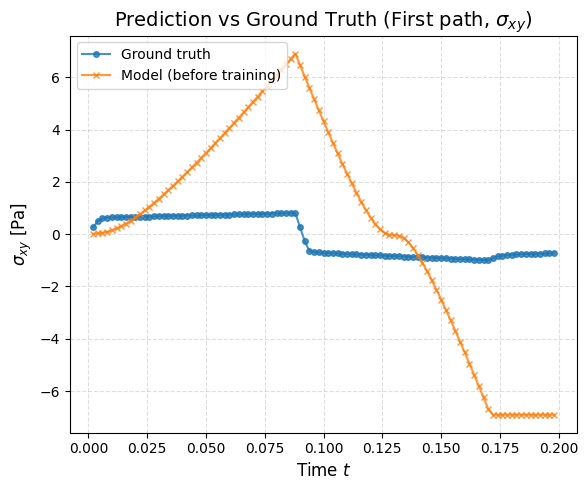

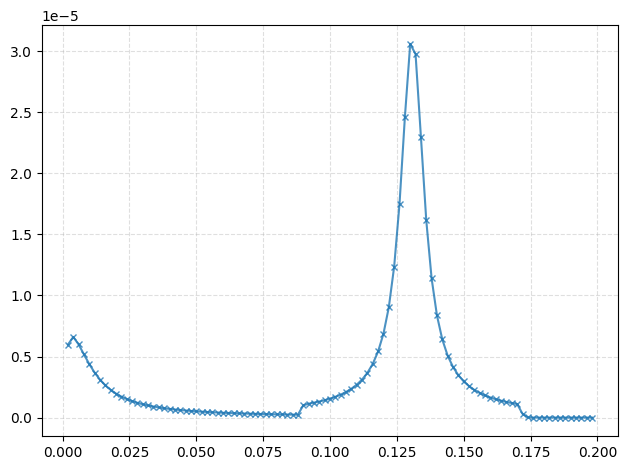

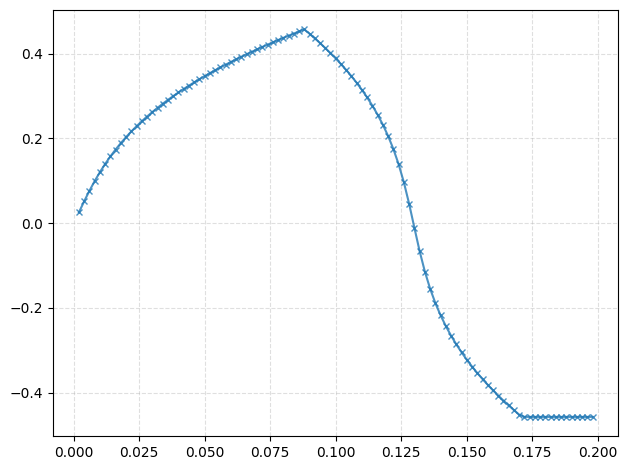

In [90]:
i_path = 1

plt.figure(figsize=(6, 5))

# Ground truth
plt.plot(
    times[i_path, 1:], 
    train_stress[i_path, :, 0, 1], 
    marker='o', markersize=4, linewidth=1.5, alpha=0.8,
    label="Ground truth"
)

# Prediction before training
plt.plot(
    times[i_path, 1:], 
    sig_train[i_path, :, 0, 1], 
    marker='x', markersize=4, linewidth=1.5, alpha=0.8,
    label="Model (before training)"
)

plt.xlabel("Time $t$", fontsize=12)
plt.ylabel(r"$\sigma_{xy}$ [Pa]", fontsize=12)
plt.title("Prediction vs Ground Truth (First path, $\sigma_{xy}$)", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

plt.figure()

plt.plot(
    times[i_path, 1:], 
    # state_train.internal.alpha[i_path, :,0,1], 
    # state_train.strain[i_path, :,0,1], 
    state_train.internal.p[i_path, :], 
    marker='x', markersize=4, linewidth=1.5, alpha=0.8,
    label="Model (before training)"
)
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

plt.figure()

plt.plot(
    times[i_path, 1:], 
    state_train.internal.epsp[i_path, :, 0,1], 
    # state_train.internal.p[i_path, :], 
    marker='x', markersize=4, linewidth=1.5, alpha=0.8,
    label="Model (before training)"
)
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## Training

In [ ]:
sig_noise = SymmetricTensor2(tensor=train_stress) # first train on one path

learning_rate = 5e-2
max_steps = 500
optimizer = optax.chain(
    optax.scale_by_adam(),
    optax.scale_by_param_block_rms(),
    optax.scale(-learning_rate),
)

# --- Loss function ---
@eqx.filter_jit
def loss_fn(params, args):
    sig_data, static_ = args
    material_ = params if static_ is None else eqx.combine(params, static_)
    sig_hat = batched_compute_evolution(material_, train_strain, times_train, False)
    diff = sig_hat.array - sig_data.array
    loss_val = 0.5 * jnp.mean(diff**2)
    return loss_val, sig_hat

# --- Gradient step ---
@jax.jit
def step(params, opt_state, args):
    (loss_val, sig_hat), grads = jax.value_and_grad(loss_fn, has_aux=True)(params, args)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_val, sig_hat

# --- Boucle sur gsm / Nvar ---
# trainable, static = partition_by_node_names(gsm, ["free_energy.elasticity"])
trainable, static = eqx.partition(gsm, eqx.is_array)

# initialisation optimizer
params = trainable
opt_state = optimizer.init(params)

# Training loop
for step_idx in range(max_steps):
    params, opt_state, loss_val, sig_hat_train = step(params, opt_state, (sig_noise, static))

    if step_idx % 1 == 0:
        print(f"Step {step_idx}: loss = {float(loss_val):.6e}")

# Combiner trainable + static pour obtenir le matériau complet
trained_material = params if static is None else eqx.combine(params, static)


Step 0: loss = 1.795187e+00
Step 1: loss = 1.520774e+00
Step 2: loss = 1.285613e+00
Step 3: loss = 1.085021e+00
Step 4: loss = 9.146626e-01
Step 5: loss = 7.705644e-01
Step 6: loss = 6.491213e-01
Step 7: loss = 5.470990e-01
Step 8: loss = 4.616260e-01
Step 9: loss = 3.901769e-01
Step 10: loss = 3.305506e-01
Step 11: loss = 2.808437e-01
Step 12: loss = 2.394208e-01
Step 13: loss = 2.048843e-01
Step 14: loss = 1.760450e-01
Step 15: loss = 1.518933e-01
Step 16: loss = 1.315733e-01
Step 17: loss = 1.143604e-01
Step 18: loss = 9.964379e-02
Step 19: loss = 8.691767e-02
Step 20: loss = 7.578623e-02
Step 21: loss = 6.599635e-02
Step 22: loss = 5.752405e-02
Step 23: loss = 5.074815e-02
Step 24: loss = 4.647685e-02
Step 25: loss = 4.450654e-02
Step 26: loss = 4.200834e-02
Step 27: loss = 3.825357e-02
Step 28: loss = 3.436937e-02
Step 29: loss = 3.125444e-02
Step 30: loss = 2.913655e-02
Step 31: loss = 2.779726e-02
Step 32: loss = 2.689722e-02
Step 33: loss = 2.616298e-02
Step 34: loss = 2.542948

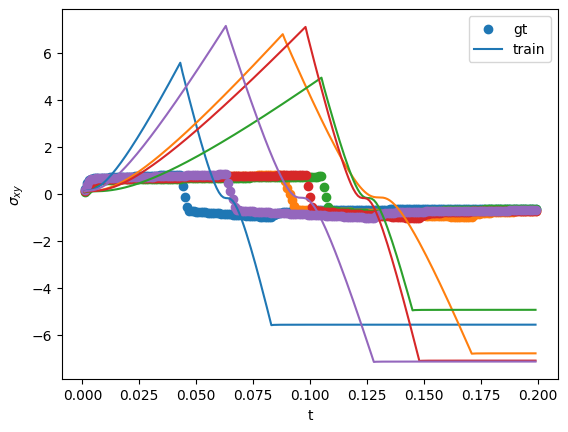

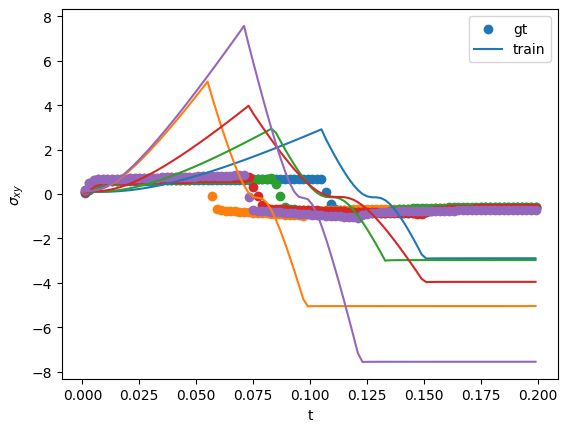

In [ ]:
for i in range(5):
    label_gt = 'gt' if i == 0 else None
    label_train = 'train' if i==0 else None
    plt.scatter(times_train[i,1:].T, train_stress[i, :, 0, 1].T, label = label_gt)
    plt.plot(times_train[i,1:].T, sig_hat_train[i, :, 0, 1].T, label = label_train)
plt.xlabel("t")
plt.ylabel("$\sigma_{xy}$")

plt.legend()
plt.show()

sig_hat_test = batched_compute_evolution(trained_material, test_strain, times_test, False)
for i in range(5):
    label_gt = 'gt' if i == 0 else None
    label_train = 'train' if i==0 else None
    plt.scatter(times_test[i,1::2].T, test_stress[i, ::2, 0, 1].T, label = label_gt)
    plt.plot(times_test[i,1::2].T, sig_hat_test[i, ::2, 0, 1].T, label = label_train)
plt.xlabel("t")
plt.ylabel("$\sigma_{xy}$")

plt.legend()
plt.show()

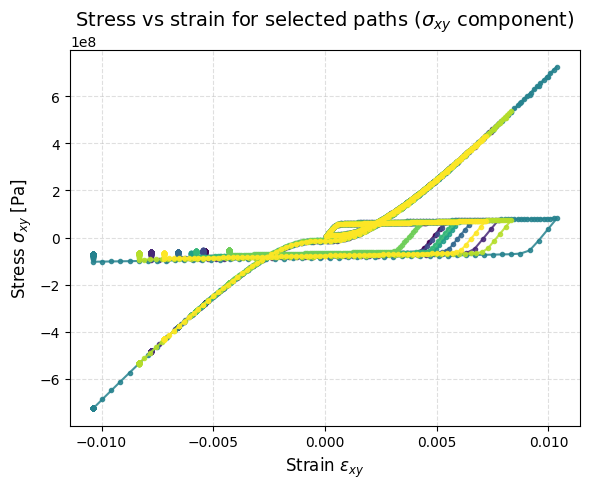

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

for i in range(n_paths):
    ax.plot(
        test_strain[i, :, 0,1] * scalers["std_strain"][3],  # ε_xy
        sig_hat_test[i, :, 0,1] * scalers["std_stress"][3],  # σ_xy
        color=colors[i],
        marker='o',
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
    )
    ax.plot(
            test_strain[i, :, 0,1] * scalers["std_strain"][3],  # ε_xy
            test_stress[i, :, 0,1] * scalers["std_stress"][3],  # σ_xy
            color=colors[i],
            marker='o',
            markersize=3,
            linewidth=1.5,
            alpha=0.85,
        )

ax.set_xlabel(r"Strain $\varepsilon_{xy}$", fontsize=12)
ax.set_ylabel(r"Stress $\sigma_{xy}$ [Pa]", fontsize=12)
ax.set_title("Stress vs strain for selected paths ($\sigma_{xy}$ component)", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

In [ ]:
plt.scatter(test_stress[...,0,1].flatten(), sig_hat_test[...,0,1].flatten())

In [ ]:
_,state_train = batched_compute_evolution(trained_material, train_strain, times_train, True)

In [ ]:
state_train

In [ ]:
state_train.internal.p.shape
s_p = jax.vmap(jax.vmap(dev))(state_train.internal.epsp)
norm_sp = jnp.sqrt(3 / 2.0) * jax.vmap(jax.vmap(safe_norm))(s_p)

In [ ]:
s_p

In [ ]:
plt.plot(state_train.internal.p[0,...])

plt.figure()
plt.plot(norm_sp.T)


In [ ]:
sig_hat_test, state_hat_test = batched_compute_evolution(trained_material, test_strain, times_test, True)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

for i in range(10):
    ax.plot(
        train_strain[i, :, k, l] * scalers["std_strain"][3],  # ε_xy
        train_stress[i, :, k, l] * scalers["std_stress"][3],  # σ_xy
        color=colors[i],
        # marker='o',
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
    )
    ax.plot(
        train_strain[i, :, k, l] * scalers["std_strain"][3],  # ε_xy
        sig_hat_train[i, :, k, l] * scalers["std_stress"][3],  # σ_xy
        color=colors[i],
        marker='o',
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
    )
sig_hat_train[i, :, 0, 1]

ax.set_xlabel(r"Strain $\varepsilon_{xy}$", fontsize=12)
ax.set_ylabel(r"Stress $\sigma_{xy}$ [Pa]", fontsize=12)
ax.set_title("Stress vs strain for selected paths ($\sigma_{xy}$ component)", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()


In [ ]:
plt.plot(state_hat_test.internal.p[0,:,0])

# Conversion for MFront

In [ ]:
def evolution(sigma:jnp.array, p:jnp.array):
    '''
    function that take the 6 composant of epsilon in mandel notation as well as alpha does.'''
    # epsilon = jnp.asarray(epsilon)
    # alpha = jnp.asarray(alpha)
    sigma /= scalers["std_stress"][3]
    # p /= scalers["std_strain"][3]
    sigma_ = SymmetricTensor2(array=sigma)
    dot_isv = trained_material.evolution(sigma_, p)
    return dot_isv.epsp.array * scalers["std_strain"][3], dot_isv.p #* scalers["std_strain"][3]

def phi2_and_derivatives(sigma, p:jnp.array):
    """
    Compute dotalpha, dotalpha/depsp and dotalpha/depsp in a single call to JAX.
    """
    phi2 = evolution(sigma, p)
    J = jax.jacfwd(evolution, argnums=(0,1))(sigma,p)
    ddepsp_depsp = J[0][0]
    ddepsp_dp = J[0][1]
    ddp_depsp = J[1][0]
    ddp_dp = J[1][1]
    return {"epsp_dot":phi2[0],"p_dot":phi2[1],"ddepsp_depsp":ddepsp_depsp,
    "ddepsp_dp":ddepsp_dp,
    "ddp_depsp":ddp_depsp,
    "ddp_dp":ddp_dp}

In [ ]:
sigma = jax.random.normal(key=key1, shape=(6,))
epsp = jax.random.normal(key=key2, shape=(6,))
p = jax.random.normal(key=key, shape=(1,))
# stress(epsilon, epsp, p)
# evolution(epsilon, epsp, p)
phi2_and_derivatives(sigma, p)

In [ ]:
from jax.experimental import jax2tf
import tensorflow as tf

# --- Conversion d'évolution (phi2) ---
phi2_tf = tf.function(
    jax2tf.convert(phi2_and_derivatives, with_gradient=False, enable_xla=False),
    input_signature=[
        tf.TensorSpec(shape=(6,), dtype=tf.float64, name="sigma"),
        tf.TensorSpec(shape=(1,), dtype=tf.float64, name="p"),
    ],
)


In [ ]:
class ConstitutiveModel(tf.Module):
    def __init__(self):
        super().__init__()
        # self.phi1 = phi1_tf
        self.phi2 = phi2_tf

model = ConstitutiveModel()

In [ ]:
sig = tf.zeros((6,), dtype=tf.float64)
p = tf.zeros((1,), dtype=tf.float64)

phi2 = model.phi2(sig, p)

print("phi_2:", phi2)

tf.saved_model.save(
    model,
    export_dir="./model/norton_hardening_nn",
    signatures={
        "phi2": model.phi2
    }
)